In [1]:
# ============================================================
# 0. 导入需要用到的 Python 库
# ============================================================
# os / glob：用于处理文件路径、自动查找文件
import os
import glob
import warnings
# numpy：数值计算，后面 CNN 输入矩阵 X 会用 numpy 数组保存
import numpy as np
# pandas：读取和处理表格时间序列数据，比如 GESLA 潮位数据
import pandas as pd
# matplotlib：画图检查数据是否正常
import matplotlib.pyplot as plt
# xarray：读取 ERA20C 的 grib 气象数据
import xarray as xr
# sklearn：标准化、数据划分
from sklearn.preprocessing import StandardScaler
# UTide：做潮汐调和分析，用于潮汐分离
from utide import solve, reconstruct
# matplotlib.dates：把 datetime 时间转成 UTide 可用的数值时间
import matplotlib.dates as mdates
# 忽略一些不影响运行的警告
warnings.filterwarnings("ignore")

d:\anaconda\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [15]:
# ============================================================
# 1. 设置路径和站点基本信息
# ============================================================

# 当前测试年份
# 你现在只复制了 1985 年 ERA20C，所以这里先写 1985
YEAR = 1985

# 数据总目录
BASE_DIR = r"E:\AAAqian\code\storm_surge\data"

# ERA20C 数据目录
ERA_DIR = os.path.join(BASE_DIR, "ERA20C_1985")

# 厦门 GESLA 潮位文件路径
GESLA_FILE = os.path.join(
    BASE_DIR,
    "xiamen_GESLA",
    "xiamen-376a-chn-uhslc"
)

# 预处理结果输出目录
OUT_DIR = os.path.join(BASE_DIR, "processed_xiamen_1985")
os.makedirs(OUT_DIR, exist_ok=True)

# 厦门站基本信息
# 这些信息来自 GESLA 文件头部
SITE_NAME = "Xiamen"
SITE_LAT = 24.45
SITE_LON = 118.067

# 自动查找 1985 年的三个 ERA20C 文件
U10_FILE = glob.glob(os.path.join(ERA_DIR, "10U", f"*{YEAR}*.grb"))[0]
V10_FILE = glob.glob(os.path.join(ERA_DIR, "10V", f"*{YEAR}*.grb"))[0]
SLP_FILE = glob.glob(os.path.join(ERA_DIR, "SLP", f"*{YEAR}*.grb"))[0]

print("U10 文件:", U10_FILE)
print("V10 文件:", V10_FILE)
print("SLP 文件:", SLP_FILE)
print("GESLA 文件:", GESLA_FILE)

U10 文件: E:\AAAqian\code\storm_surge\data\ERA20C_1985\10U\e20c.oper.an.sfc.3hr.128_165_10u.regn80sc.1985010100_1985123121.grb
V10 文件: E:\AAAqian\code\storm_surge\data\ERA20C_1985\10V\e20c.oper.an.sfc.3hr.128_166_10v.regn80sc.1985010100_1985123121.grb
SLP 文件: E:\AAAqian\code\storm_surge\data\ERA20C_1985\SLP\e20c.oper.an.sfc.3hr.128_151_msl.regn80sc.1985010100_1985123121.grb
GESLA 文件: E:\AAAqian\code\storm_surge\data\xiamen_GESLA\xiamen-376a-chn-uhslc


In [16]:
# ============================================================
# 2. 找到 GESLA 文件中真正数据开始的行
# ============================================================

def find_data_start_line(file_path):
    """
    GESLA 文件前面有很多以 # 开头的说明信息，
    比如站点名、经纬度、时间范围等。

    真正的潮位数据从第一个“不以 # 开头”的行开始。
    这个函数就是自动找到数据开始的行号。
    """

    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            if not line.startswith("#"):
                return i

    raise ValueError("没有找到数据开始行，请检查 GESLA 文件格式。")


start_line = find_data_start_line(GESLA_FILE)
print("GESLA 数据开始行:", start_line)

GESLA 数据开始行: 41


In [17]:
# ============================================================
# 3. 读取 GESLA 原始潮位数据
# ============================================================

raw = pd.read_csv(
    GESLA_FILE,
    skiprows=start_line,       # 跳过文件头部注释
    delim_whitespace=True,     # GESLA 数据一般用空格分隔
    header=None                # 原始文件没有表头
)

print("原始数据前5行:")
display(raw.head())

print("原始数据形状:", raw.shape)

原始数据前5行:


,0,1,2,3,4
0,1954/01/01,00:00:00,4.50,1,1
1,1954/01/01,01:00:00,4.92,1,1
2,1954/01/01,02:00:00,5.08,1,1
3,1954/01/01,03:00:00,4.80,1,1
4,1954/01/01,04:00:00,4.14,1,1


原始数据形状: (385696, 5)


In [18]:
# ============================================================
# 4. 给 GESLA 数据添加列名，并整理时间
# ============================================================

# 常见 GESLA 数据列一般是：
# 第1列：日期
# 第2列：时间
# 第3列：水位 sea_level
# 第4列：质量控制标记 qc_flag
# 第5列：使用标记 use_flag

print("GESLA 原始列数:", raw.shape[1])

if raw.shape[1] >= 5:
    raw = raw.iloc[:, :5]
    raw.columns = ["date", "time", "sea_level", "qc_flag", "use_flag"]

elif raw.shape[1] == 4:
    raw.columns = ["date", "time", "sea_level", "qc_flag"]
    raw["use_flag"] = 1

else:
    raise ValueError("GESLA 列数不符合预期，请先查看 raw.head()。")


# 合并 date 和 time，生成 datetime 时间列
raw["datetime"] = pd.to_datetime(
    raw["date"].astype(str) + " " + raw["time"].astype(str),
    errors="coerce"
)

# 将水位列转成数字
raw["sea_level"] = pd.to_numeric(raw["sea_level"], errors="coerce")

# 只保留后面需要的列
df = raw[["datetime", "sea_level", "qc_flag", "use_flag"]].copy()

# 删除时间或水位为空的数据
df = df.dropna(subset=["datetime", "sea_level"])

# 按时间排序
df = df.sort_values("datetime")

# 删除重复时间
df = df.drop_duplicates(subset=["datetime"])

display(df.head())
display(df.tail())

print("整理后数据形状:", df.shape)

GESLA 原始列数: 5


,datetime,sea_level,qc_flag,use_flag
0,1954-01-01 00:00:00,4.50,1,1
1,1954-01-01 01:00:00,4.92,1,1
2,1954-01-01 02:00:00,5.08,1,1
3,1954-01-01 03:00:00,4.80,1,1
4,1954-01-01 04:00:00,4.14,1,1


,datetime,sea_level,qc_flag,use_flag
385691,1997-12-31 11:00:00,2.05,1,1
385692,1997-12-31 12:00:00,1.94,1,1
385693,1997-12-31 13:00:00,2.62,1,1
385694,1997-12-31 14:00:00,3.63,1,1
385695,1997-12-31 15:00:00,4.52,1,1


整理后数据形状: (385696, 4)


In [19]:
# ============================================================
# 5. 筛选 1985 年数据，并处理明显缺测值
# ============================================================

# 只保留 1985 年
df = df[df["datetime"].dt.year == YEAR].copy()

# GESLA 或潮位数据里常见的缺测值标记
# 不同数据集可能会用 -99, -999, -9999, 9999 等表示缺测
bad_values = [-99, -999, -9999, 9999, 99999]

# 将这些异常缺测值替换成 NaN
df.loc[df["sea_level"].isin(bad_values), "sea_level"] = np.nan

# 如果 use_flag 为 0，通常表示不推荐使用
# 这里做一个宽松处理：只删除 use_flag == 0 的数据
df = df[df["use_flag"] != 0].copy()

# 删除缺测水位
df = df.dropna(subset=["sea_level"])

print("1985 年清洗前基本统计:")
display(df["sea_level"].describe())

print("1985 年数据量:", df.shape)
display(df.head())

1985 年清洗前基本统计:


count    8760.000000
mean        3.581476
std         1.436391
min         0.360000
25%         2.400000
50%         3.510000
75%         4.830000
max         6.810000
Name: sea_level, dtype: float64

1985 年数据量: (8760, 4)


,datetime,sea_level,qc_flag,use_flag
271752,1985-01-01 00:00:00,4.56,1,1
271753,1985-01-01 01:00:00,4.19,1,1
271754,1985-01-01 02:00:00,3.60,1,1
271755,1985-01-01 03:00:00,3.02,1,1
271756,1985-01-01 04:00:00,2.60,1,1


In [20]:
# ============================================================
# 6. 对原始潮位进行异常值处理
# ============================================================

def clean_sea_level_outliers(data, col="sea_level"):
    """
    对潮位数据进行异常值处理。

    这里用了两层清洗：

    1. 物理阈值：
       先删除特别离谱的数值，比如大于 10000 或小于 -10000。
       这里阈值设得比较宽松，是为了避免误删真实风暴潮。

    2. IQR 方法：
       IQR = Q3 - Q1
       正常情况下，超过 Q1 - 5*IQR 或 Q3 + 5*IQR 的点视为异常。
       这里使用 5*IQR，而不是常见的 1.5*IQR，
       是因为潮位和风暴潮本来就可能有极端值，不能删得太严格。

    异常值不直接删除，而是先设为 NaN，再用时间插值补齐。
    """

    data = data.copy()

    # 第一步：物理阈值粗筛
    data = data[(data[col] > -10000) & (data[col] < 10000)].copy()

    # 第二步：IQR 异常值判断
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 5 * iqr
    upper = q3 + 5 * iqr

    data["is_outlier"] = (data[col] < lower) | (data[col] > upper)

    print("潮位 Q1:", q1)
    print("潮位 Q3:", q3)
    print("潮位 IQR:", iqr)
    print("潮位异常值下限:", lower)
    print("潮位异常值上限:", upper)
    print("潮位异常值数量:", data["is_outlier"].sum())

    # 将异常值设为 NaN
    data.loc[data["is_outlier"], col] = np.nan

    # 按时间设索引，方便时间插值
    data = data.set_index("datetime").sort_index()

    # 时间插值
    # limit=6 表示最多连续补 6 个缺测点
    # 如果有大段缺测，不强行补
    data[col] = data[col].interpolate(
        method="time",
        limit=6,
        limit_direction="both"
    )

    # 删除仍然无法补齐的缺测值
    data = data.dropna(subset=[col])

    # 恢复 datetime 为普通列
    data = data.reset_index()

    return data


df_clean = clean_sea_level_outliers(df)

print("清洗后数据量:", df_clean.shape)
display(df_clean.head())

潮位 Q1: 2.4
潮位 Q3: 4.83
潮位 IQR: 2.43
潮位异常值下限: -9.75
潮位异常值上限: 16.98
潮位异常值数量: 0
清洗后数据量: (8760, 5)


,datetime,sea_level,qc_flag,use_flag,is_outlier
0,1985-01-01 00:00:00,4.56,1,1,False
1,1985-01-01 01:00:00,4.19,1,1,False
2,1985-01-01 02:00:00,3.60,1,1,False
3,1985-01-01 03:00:00,3.02,1,1,False
4,1985-01-01 04:00:00,2.60,1,1,False


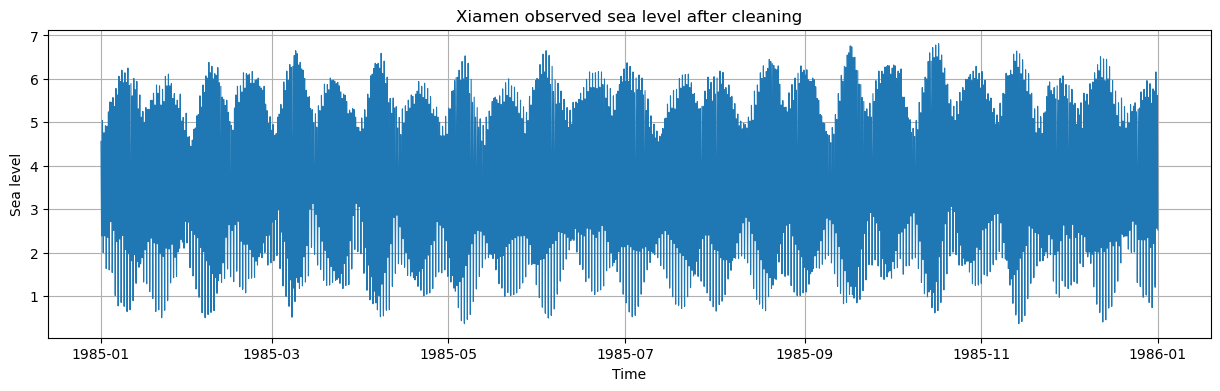

In [21]:
# ============================================================
# 7. 画图检查清洗后的原始潮位
# ============================================================

plt.figure(figsize=(15, 4))
plt.plot(df_clean["datetime"], df_clean["sea_level"], linewidth=0.8)
plt.title("Xiamen observed sea level after cleaning")
plt.xlabel("Time")
plt.ylabel("Sea level")
plt.grid(True)
plt.show()

In [22]:
# ============================================================
# 8. 使用 UTide 做潮汐调和分析
# ============================================================

# 注意：
# 这里为了跑通流程，只使用 1985 年数据做调和分析。
# 但正式复现论文时，建议使用厦门站完整观测期 1954–1997，
# 因为调和分析需要较长时间序列，结果会更稳定。

# 将 datetime 转成 UTide 可以识别的数值时间
time_num = mdates.date2num(df_clean["datetime"])

# 原始观测潮位
sea_level = df_clean["sea_level"].values

# solve：根据观测潮位估计主要分潮参数
coef = solve(
    time_num,
    sea_level,
    lat=SITE_LAT,
    method="ols",
    conf_int="linear"
)

print("潮汐调和分析完成。")

solve: matrix prep ... solution ... done.
潮汐调和分析完成。


prep/calcs ... done.


,datetime,sea_level,qc_flag,use_flag,is_outlier,tide,storm_surge
0,1985-01-01 00:00:00,4.56,1,1,False,3.499557,1.060443
1,1985-01-01 01:00:00,4.19,1,1,False,3.499557,0.690443
2,1985-01-01 02:00:00,3.60,1,1,False,3.499557,0.100443
3,1985-01-01 03:00:00,3.02,1,1,False,3.499557,-0.479557
4,1985-01-01 04:00:00,2.60,1,1,False,3.499557,-0.899557


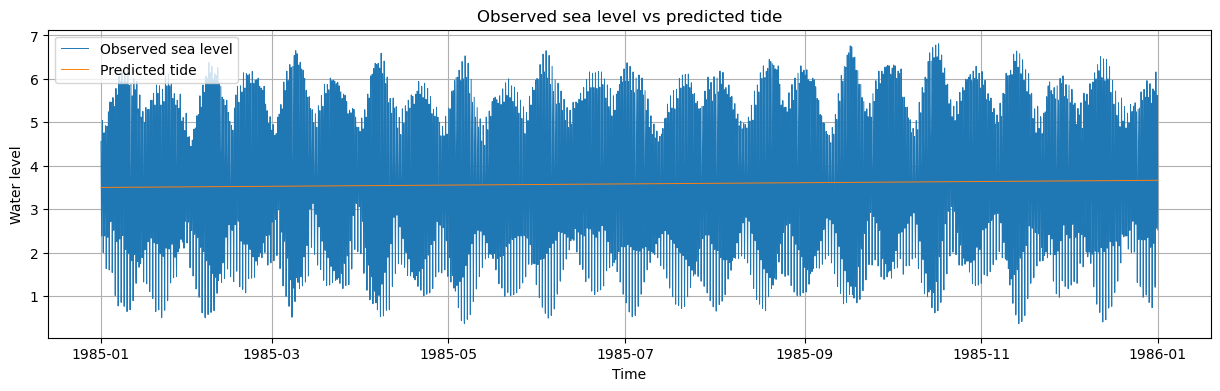

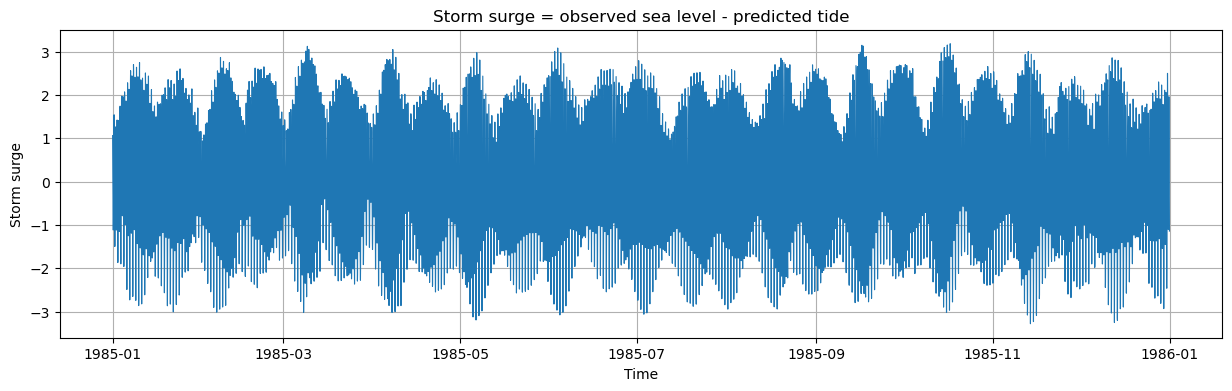

In [23]:
# ============================================================
# 9. 根据调和分析结果重建天文潮，并计算 storm surge
# ============================================================

# reconstruct：根据分潮参数重建天文潮 tide
tide = reconstruct(time_num, coef)

# 添加天文潮
df_clean["tide"] = tide.h

# 风暴潮 = 实测水位 - 天文潮
df_clean["storm_surge"] = df_clean["sea_level"] - df_clean["tide"]

display(df_clean.head())

plt.figure(figsize=(15, 4))
plt.plot(df_clean["datetime"], df_clean["sea_level"], label="Observed sea level", linewidth=0.7)
plt.plot(df_clean["datetime"], df_clean["tide"], label="Predicted tide", linewidth=0.7)
plt.title("Observed sea level vs predicted tide")
plt.xlabel("Time")
plt.ylabel("Water level")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 4))
plt.plot(df_clean["datetime"], df_clean["storm_surge"], linewidth=0.8)
plt.title("Storm surge = observed sea level - predicted tide")
plt.xlabel("Time")
plt.ylabel("Storm surge")
plt.grid(True)
plt.show()